# AI Campaign Performance Scoring Decision-Support System

## Project objective
The objective of this project is to build an explainable campaign scoring system that helps marketing teams prioritize campaigns by expected performance. The goal is not only to predict outcomes, but to support better budget allocation and faster decision-making.

This project is being developed with a Responsible AI mindset. The goal is not only to predict campaign performance, but to do so in a way that is explainable, business-oriented, and mindful of how model outputs may influence marketing decisions. The system should support human judgment rather than replace it.

## Business problem
Marketing teams often have campaign records but no simple way to identify which campaigns are likely to perform well. This project addresses that problem by turning raw campaign data into a ranked and explainable decision-support output.

## Target definition
The target is defined as a binary label, where high-performing campaigns are separated from lower-performing campaigns based on conversion performance. This creates a clear business outcome that can be used for ranking and prioritization.

The primary target will be a binary label:
- `high_performing_campaign = 1` if `Conversion_Rate` is in the top quartile
- `0` otherwise

## Leakage rule
`Conversion_Rate` and `ROI` are outcome variables. They help define and interpret performance, but they should not be used as direct inputs to the model because that would leak future information into the training process.

## Scope
This project focuses on:
- data understanding
- feature engineering
- model training
- explainability
- a simple decision-support dashboard

## Data Loading and Inspection

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

DATA_PATH = r'C:\Users\oha14\Projects\AI Campus Cohort 2 -Business Data\marketing_project\data\raw\marketing_campaign_dataset.csv'
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (200000, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

None

### Basic Data Summary

In [7]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().sum().values / len(df) * 100).round(2),
})

display(summary.sort_values("missing_pct", ascending=False))
display(df.describe(include="all").T)

,column,dtype,missing_count,missing_pct
0,Campaign_ID,int64,0,0.0
1,Company,object,0,0.0
2,Campaign_Type,object,0,0.0
3,Target_Audience,object,0,0.0
4,Duration,object,0,0.0
5,Channel_Used,object,0,0.0
6,Conversion_Rate,float64,0,0.0
7,Acquisition_Cost,object,0,0.0
8,ROI,float64,0,0.0
9,Location,object,0,0.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Campaign_ID,200000.0,NaN,NaN,NaN,100000.5,57735.171256,1.0,50000.75,100000.5,150000.25,200000.0
Company,200000,5,TechCorp,40237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Campaign_Type,200000,5,Influencer,40169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Target_Audience,200000,5,Men 18-24,40258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,200000,4,30 days,50255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel_Used,200000,6,Email,33599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Conversion_Rate,200000.0,NaN,NaN,NaN,0.08007,0.040602,0.01,0.05,0.08,0.12,0.15
Acquisition_Cost,200000,15001,"$16,578.00",32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROI,200000.0,NaN,NaN,NaN,5.002438,1.734488,2.0,3.5,5.01,6.51,8.0
Location,200000,5,Miami,40269,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Define the Target

In [8]:
df["Conversion_Rate"] = pd.to_numeric(df["Conversion_Rate"], errors="coerce")
threshold = df["Conversion_Rate"].quantile(0.75)
df["high_performing_campaign"] = (df["Conversion_Rate"] >= threshold).astype(int)

print("Target threshold:", threshold)
print(df["high_performing_campaign"].value_counts())
print(df["high_performing_campaign"].value_counts(normalize=True).round(4))

Target threshold: 0.12
high_performing_campaign
0    149984
1     50016
Name: count, dtype: int64
high_performing_campaign
0    0.7499
1    0.2501
Name: proportion, dtype: float64


### Check Data Leakage

In [9]:
feature_plan = pd.DataFrame([
    {"column": "Conversion_Rate", "use": "target only", "reason": "Defines campaign performance"},
    {"column": "ROI", "use": "analysis only", "reason": "Outcome variable, not a pre-campaign input"},
    {"column": "Clicks", "use": "feature", "reason": "Available campaign behavior"},
    {"column": "Impressions", "use": "feature", "reason": "Available campaign behavior"},
    {"column": "Engagement_Score", "use": "feature", "reason": "Direct engagement signal"},
    {"column": "Date", "use": "feature", "reason": "Supports time-based patterns"},
])

display(feature_plan)

,column,use,reason
0,Conversion_Rate,target only,Defines campaign performance
1,ROI,analysis only,"Outcome variable, not a pre-campaign input"
2,Clicks,feature,Available campaign behavior
3,Impressions,feature,Available campaign behavior
4,Engagement_Score,feature,Direct engagement signal
5,Date,feature,Supports time-based patterns


### Data Overview
Before modeling, it is important to understand the structure, scale, and quality of the dataset. This helps establish whether the data is suitable for scoring, what patterns are visible, and where feature engineering may be needed.

In [11]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# Preview
display(df.head())

Shape: (200000, 17)

Columns:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date', 'high_performing_campaign']

Data types:
Campaign_ID                   int64
Company                      object
Campaign_Type                object
Target_Audience              object
Duration                     object
Channel_Used                 object
Conversion_Rate             float64
Acquisition_Cost             object
ROI                         float64
Location                     object
Language                     object
Clicks                        int64
Impressions                   int64
Engagement_Score              int64
Customer_Segment             object
Date                         object
high_performing_campaign      int64
dtype: object


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,high_performing_campaign
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,0
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,1
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,0
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,0
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,0


#### Check for missing Values and Duplicates

In [16]:
# Missing values and duplicates
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

display(missing)

print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_pct
Campaign_ID,0,0.0
Location,0,0.0
Date,0,0.0
Customer_Segment,0,0.0
Engagement_Score,0,0.0
Impressions,0,0.0
Clicks,0,0.0
Language,0,0.0
ROI,0,0.0
Company,0,0.0


Duplicate rows: 0


In [17]:
# Numeric summary
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Campaign_ID,200000.0,100000.500000,57735.171256,1.00,50000.75,100000.50,150000.25,200000.00
Conversion_Rate,200000.0,0.080070,0.040602,0.01,0.05,0.08,0.12,0.15
ROI,200000.0,5.002438,1.734488,2.00,3.50,5.01,6.51,8.00
Clicks,200000.0,549.772030,260.019056,100.00,325.00,550.00,775.00,1000.00
Impressions,200000.0,5507.301520,2596.864286,1000.00,3266.00,5517.50,7753.00,10000.00
Engagement_Score,200000.0,5.494710,2.872581,1.00,3.00,5.00,8.00,10.00
high_performing_campaign,200000.0,0.250080,0.433060,0.00,0.00,0.00,1.00,1.00


The dataset is in good analytical shape. There are no missing values, no duplicate rows, and the data types are already consistent with the expected schema. This means the main challenge is not data repair, but extracting useful business patterns and building meaningful features that can support campaign scoring.

Because the raw data quality is already strong, the next step is not cleaning, but understanding how campaign performance varies across campaign type, audience, channel, geography, language, and customer segment. That is where the business signal will come from.

#### Target Distribution

In [14]:
# Target distribution
target_counts = df["high_performing_campaign"].value_counts()
target_pct = df["high_performing_campaign"].value_counts(normalize=True).round(4)

print("Target counts:")
print(target_counts)

print("\nTarget proportions:")
print(target_pct)

Target counts:
high_performing_campaign
0    149984
1     50016
Name: count, dtype: int64

Target proportions:
high_performing_campaign
0    0.7499
1    0.2501
Name: proportion, dtype: float64


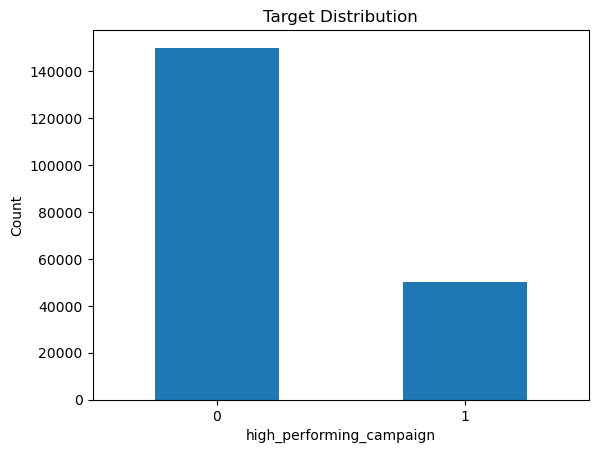

In [15]:
import matplotlib.pyplot as plt

target_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("high_performing_campaign")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The target is moderately imbalanced, with about 75% of campaigns labeled as not high performing and 25% labeled as high performing. This is a realistic setup for a prioritization problem because high-performing campaigns are naturally less common than average ones. The imbalance is not extreme, but it is important enough to consider class weighting, threshold tuning, and ranking-based evaluation such as top-decile lift rather than relying only on accuracy.

This distribution suggests that the model should be judged not only by overall classification accuracy, but also by its ability to rank the most promising campaigns near the top. In a business setting, this is more useful than simply predicting the majority class well.

## Exploratory Data Analysis

This section explores how campaign performance varies across business dimensions such as campaign type, audience, channel, location, language, and customer segment. The purpose is to identify which combinations appear to be associated with stronger outcomes and which ones may need improvement.

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

def business_eda(df, category_col, target_col="high_performing_campaign", top_n=None):
    summary = (
        df.groupby(category_col)
        .agg(
            count=(target_col, "size"),
            high_perf_rate=(target_col, "mean"),
            avg_conversion_rate=("Conversion_Rate", "mean"),
            avg_roi=("ROI", "mean"),
            avg_clicks=("Clicks", "mean"),
            avg_impressions=("Impressions", "mean"),
            avg_engagement=("Engagement_Score", "mean"),
        )
        .sort_values("high_perf_rate", ascending=False)
    )

    if top_n is not None:
        summary = summary.head(top_n)

    display(summary)

    ax = summary["high_perf_rate"].plot(kind="bar", figsize=(10, 4))
    ax.set_title(f"High-Performing Rate by {category_col}")
    ax.set_xlabel(category_col)
    ax.set_ylabel("High-performing rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return summary

,count,high_perf_rate,avg_conversion_rate,avg_roi,avg_clicks,avg_impressions,avg_engagement
Campaign_Type,,,,,,,
Display,39987,0.251182,0.080089,5.006551,550.953535,5503.657589,5.505889
Influencer,40169,0.250865,0.080315,5.011068,548.623491,5496.006398,5.483134
Search,40157,0.249720,0.080021,5.008357,548.650148,5513.737057,5.487138
Social Media,39817,0.249617,0.080135,4.991784,551.415827,5501.579752,5.497878
Email,39870,0.249009,0.079788,4.994295,549.232556,5521.568272,5.499624


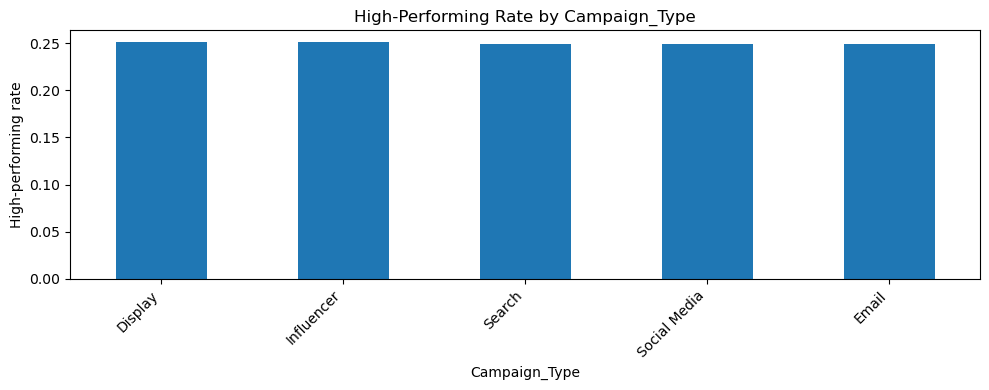

In [19]:
campaign_type_summary = business_eda(df, "Campaign_Type")

,count,high_perf_rate,avg_conversion_rate,avg_roi,avg_clicks,avg_impressions,avg_engagement
Target_Audience,,,,,,,
Women 25-34,40013,0.251643,0.079899,4.997351,551.112064,5509.452778,5.492740
All Ages,40019,0.250731,0.079975,5.005174,548.871811,5506.193108,5.487094
Women 35-44,39687,0.250283,0.080102,5.006330,549.961398,5519.256558,5.486507
Men 25-34,40023,0.249157,0.080132,5.020627,550.042176,5506.555131,5.491942
Men 18-24,40258,0.248597,0.080240,4.982853,548.879775,5495.221745,5.515078


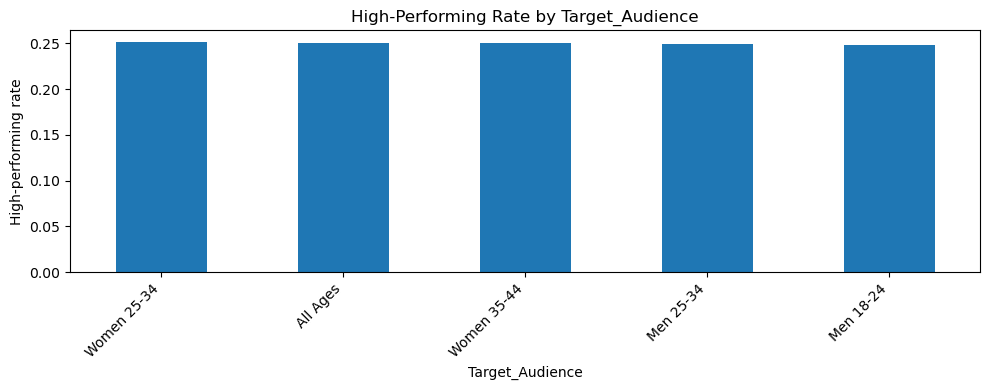

,count,high_perf_rate,avg_conversion_rate,avg_roi,avg_clicks,avg_impressions,avg_engagement
Channel_Used,,,,,,,
Website,33360,0.251888,0.080183,5.014167,551.997242,5509.782764,5.508903
Google Ads,33438,0.251750,0.080183,5.003141,548.501914,5532.833274,5.494049
Email,33599,0.250722,0.080282,4.996487,550.431947,5500.196643,5.487842
Instagram,33392,0.249641,0.079886,4.988706,548.534200,5502.469304,5.489039
Facebook,32819,0.248515,0.079992,5.018699,549.619032,5504.720680,5.503702
YouTube,33392,0.247934,0.079889,4.993754,549.545011,5493.773419,5.484937


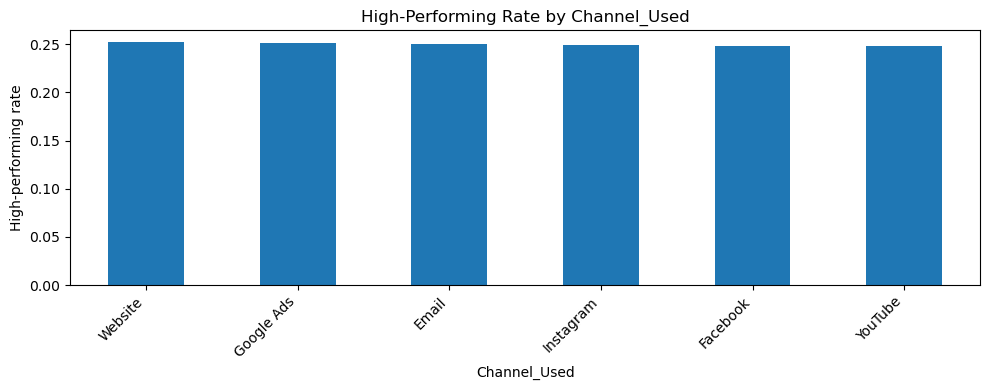

,count,high_perf_rate,avg_conversion_rate,avg_roi,avg_clicks,avg_impressions,avg_engagement
Location,,,,,,,
Miami,40269,0.252005,0.080047,5.012282,547.735603,5496.727657,5.495766
Chicago,40010,0.251212,0.080134,5.001590,549.322619,5498.200675,5.505074
New York,40024,0.249725,0.080204,4.980228,551.172871,5530.436938,5.469318
Los Angeles,39947,0.249506,0.080013,5.010876,549.892432,5498.593762,5.488823
Houston,39750,0.247925,0.079948,5.007203,550.755899,5512.629836,5.514692


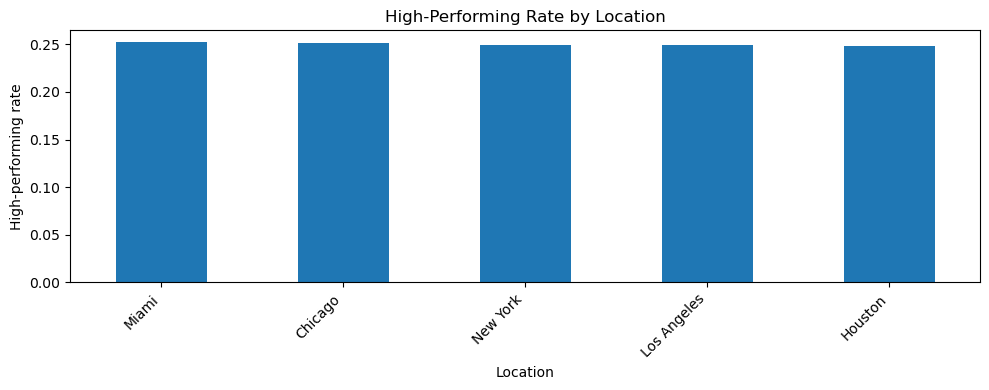

,count,high_perf_rate,avg_conversion_rate,avg_roi,avg_clicks,avg_impressions,avg_engagement
Language,,,,,,,
French,39764,0.252590,0.080254,5.011375,550.592144,5491.633362,5.468212
English,39896,0.251078,0.080169,4.990734,550.355324,5508.457389,5.497644
German,39983,0.250306,0.079973,5.001054,548.734512,5526.385314,5.505690
Mandarin,40255,0.249435,0.080036,5.007313,549.950416,5521.440840,5.505577
Spanish,40102,0.247020,0.079918,5.001705,549.233904,5488.467258,5.496210


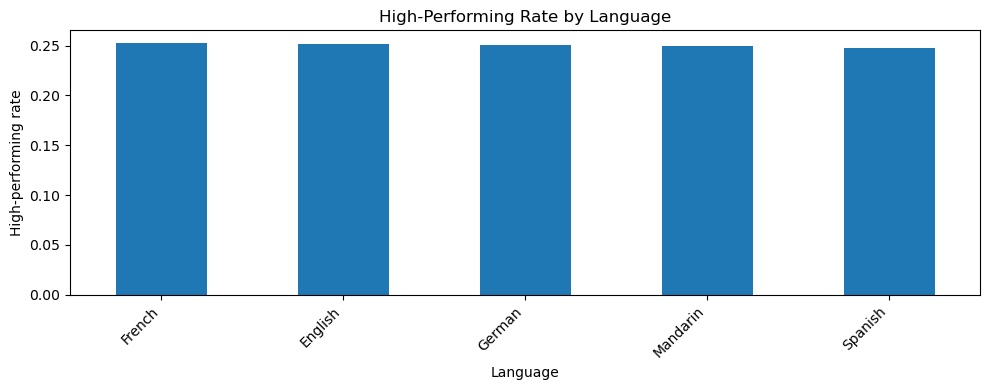

,count,high_perf_rate,avg_conversion_rate,avg_roi,avg_clicks,avg_impressions,avg_engagement
Customer_Segment,,,,,,,
Outdoor Adventurers,40011,0.252356,0.080180,4.999393,550.562420,5512.205618,5.502737
Foodies,40208,0.251890,0.080257,5.004376,549.163699,5491.820434,5.511465
Tech Enthusiasts,40151,0.250853,0.080168,5.004234,548.827974,5488.910463,5.485168
Health & Wellness,39888,0.250201,0.079945,5.003202,550.389165,5526.911803,5.484156
Fashionistas,39742,0.245056,0.079794,5.000962,549.926123,5516.924840,5.489910


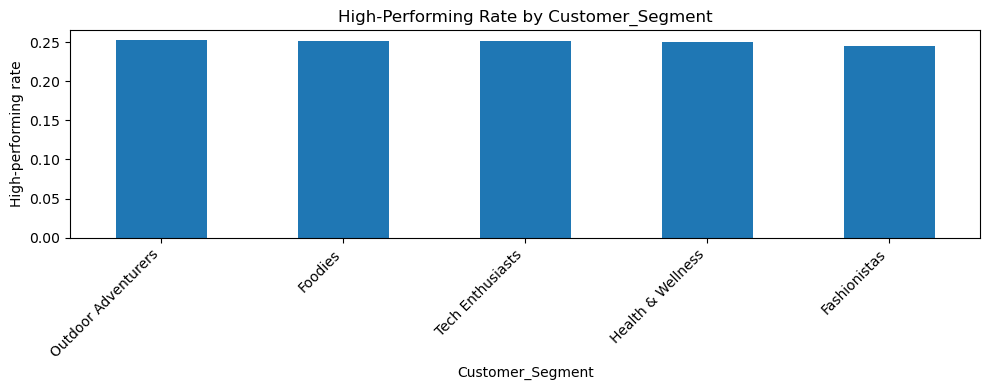

In [21]:
audience_summary = business_eda(df, "Target_Audience")
channel_summary = business_eda(df, "Channel_Used")
location_summary = business_eda(df, "Location")
language_summary = business_eda(df, "Language")
segment_summary = business_eda(df, "Customer_Segment")

Across audience, channel, location, language, and customer segment, the high-performing rate appears relatively stable. This suggests that no single categorical field is strongly dominating campaign performance by itself.

From a modeling perspective, these variables may still be useful when combined with other features such as clicks, impressions, engagement, duration, and time-based patterns.

From a Responsible AI perspective, this also prevents overclaiming that any one business category is inherently better based on a weak univariate pattern.

#### Time-based EDA

Campaign performance may change over time because of seasonality, budget cycles, market changes, or campaign fatigue. This section checks whether high-performing campaigns are more common in certain months, quarters, or days of the week. For a Responsible AI project, this helps avoid assuming that performance differences are only caused by campaign design when timing may also matter.

In [22]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["month_name"] = df["Date"].dt.month_name()
df["quarter"] = df["Date"].dt.quarter
df["day_of_week"] = df["Date"].dt.day_name()
df["is_weekend"] = df["Date"].dt.dayofweek.isin([5, 6]).astype(int)

display(df[["Date", "year", "month", "quarter", "day_of_week", "is_weekend"]].head())

,Date,year,month,quarter,day_of_week,is_weekend
0,2021-01-01,2021,1,1,Friday,0
1,2021-01-02,2021,1,1,Saturday,1
2,2021-01-03,2021,1,1,Sunday,1
3,2021-01-04,2021,1,1,Monday,0
4,2021-01-05,2021,1,1,Tuesday,0


In [23]:
time_summary = (
    df.groupby("month_name")
    .agg(
        count=("high_performing_campaign", "size"),
        high_perf_rate=("high_performing_campaign", "mean"),
        avg_conversion_rate=("Conversion_Rate", "mean"),
        avg_roi=("ROI", "mean"),
        avg_engagement=("Engagement_Score", "mean"),
    )
    .sort_values("high_perf_rate", ascending=False)
)

display(time_summary)

,count,high_perf_rate,avg_conversion_rate,avg_roi,avg_engagement
month_name,,,,,
November,16440,0.253589,0.080301,4.999271,5.457056
June,16440,0.253163,0.080078,4.985203,5.503345
December,16968,0.253124,0.080216,5.002122,5.536245
April,16440,0.252737,0.080460,4.994372,5.467214
August,16988,0.250530,0.079725,4.997793,5.472687
January,16988,0.250059,0.080084,5.014595,5.455321
March,16988,0.249411,0.080032,4.983404,5.520426
September,16440,0.248905,0.080243,5.029044,5.535097
July,16988,0.248705,0.079952,4.983045,5.498470


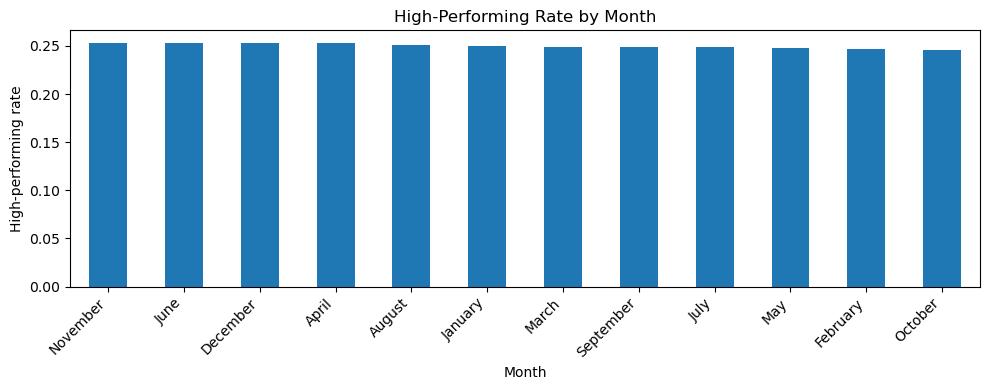

In [24]:
import matplotlib.pyplot as plt

ax = time_summary["high_perf_rate"].plot(kind="bar", figsize=(10, 4))
ax.set_title("High-Performing Rate by Month")
ax.set_xlabel("Month")
ax.set_ylabel("High-performing rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Summary of Problem Statement and Data Understanding

The dataset is structurally clean, with no missing values, no duplicate rows, and consistent data types. The target is moderately imbalanced, with about 25% of campaigns classified as high performing. Business-level EDA shows that many single categorical features do not strongly separate performance on their own, which suggests that the real signal will likely come from feature interactions, efficiency measures, and time-based patterns. This is a good sign for the project because it means feature engineering will be important and meaningful.

### Working hypotheses for feature engineering and modeling

1. Campaign efficiency features such as click-through rate and engagement efficiency will be more informative than raw counts alone.
2. Time-based features may capture subtle seasonality even if month-level differences are small.
3. Campaign type, audience, channel, and segment will likely become more useful when combined with interaction features.
4. The final model will need to be evaluated using ranking quality, not just accuracy, because the business goal is prioritization.
5. Explainability will be important because this is a Responsible AI decision-support project.